# Gravity as First Implementation Output — Maintenance-Energy Derivation of Compactness

The previous notebook made compactness

$$
C = \frac{GM}{Rc^2}
$$

the first sourced proxy for the implementation coefficient

$$
q_\Gamma = \chi C.
$$

That worked phenomenologically, but the next question is obvious:

$$
\boxed{
\text{can compactness be derived from a maintenance-cost scalar rather than inserted by hand?}
}
$$

This notebook gives the first clean derivation.

The key move is simple:

- if gravity is the first world-scale implementation of persistence,
- then the source term should be tied to the **energy cost of maintaining a closure**,
- and the first universal energy scale for a self-bound source is its self-energy.

That immediately produces compactness as the dimensionless maintenance fraction.


## 1. Maintenance-energy ansatz

Let $O$ be a source-like closure of total mass-equivalent $M$ and characteristic radius $R$.

We seek a dimensionless implementation strength $q_\Gamma$ built from the source's own maintenance burden.

The natural candidate is the fraction of rest energy tied up in self-maintenance:

$$
\boxed{
q_\Gamma \equiv \chi \frac{|E_{\mathrm{maint}}|}{M c^2},
}
$$

where:

- $E_{\mathrm{maint}}$ is the closure's self-maintenance energy,
- $\chi$ is a dimensionless implementation gain.

Now ask: what is the first universal form of $E_{\mathrm{maint}}$ for a self-bound source?

By dimensional analysis and pairwise extensivity, the unique first-order scale is

$$
\boxed{
E_{\mathrm{maint}} \sim -\,\alpha_s \frac{G M^2}{R},
}
$$

where $\alpha_s$ is a dimensionless **shape factor** encoding the internal mass profile.

Then:

$$
\boxed{
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}.
}
$$

So compactness is no longer a guess.

It emerges as the ratio of self-maintenance energy to rest energy.


## 2. Shape factors

Two standard self-energy examples are:

### Thin shell
$$
\boxed{
E_{\mathrm{shell}} = -\frac{G M^2}{2R}
}
$$

so

$$
\boxed{
\alpha_{\mathrm{shell}} = \frac{1}{2}.
}
$$

### Uniform sphere
$$
\boxed{
E_{\mathrm{sphere}} = -\frac{3}{5}\frac{G M^2}{R}
}
$$

so

$$
\boxed{
\alpha_{\mathrm{sphere}} = \frac{3}{5}.
}
$$

This is already a major gain.

It means the sourced implementation coefficient becomes

$$
\boxed{
q_\Gamma = \chi \alpha_s C,
\qquad
C=\frac{GM}{Rc^2}.
}
$$

The compactness law now has a concrete maintenance-energy interpretation.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Physical constants
G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30
R_sun = 6.957e8
M_earth = 5.9722e24
R_earth = 6.371e6

def compactness(M, R):
    return G*M/(R*c**2)

def q_gamma(M, R, chi=1.0, alpha_s=0.6):
    return chi * alpha_s * compactness(M, R)

sources = [
    ("Earth", M_earth, R_earth),
    ("Sun", M_sun, R_sun),
    ("White dwarf (0.6 Msun, 7000 km)", 0.6*M_sun, 7.0e6),
    ("Neutron star (1.4 Msun, 12 km)", 1.4*M_sun, 1.2e4),
]

rows = []
for name, M, R in sources:
    C = compactness(M, R)
    rows.append({
        "source": name,
        "compactness_C": C,
        "q_shell_chi1": q_gamma(M, R, chi=1.0, alpha_s=0.5),
        "q_sphere_chi1": q_gamma(M, R, chi=1.0, alpha_s=0.6),
    })

source_df = pd.DataFrame(rows)
source_df


,source,compactness_C,q_shell_chi1,q_sphere_chi1
0,Earth,6.961311e-10,3.480656e-10,4.176787e-10
1,Sun,2.122567e-06,1.061283e-06,1.273540e-06
2,"White dwarf (0.6 Msun, 7000 km)",1.265717e-04,6.328584e-05,7.594301e-05
3,"Neutron star (1.4 Msun, 12 km)",1.722781e-01,8.613907e-02,1.033669e-01


The difference between shell and sphere is only a shape factor of order unity.

That is exactly what we wanted:

$$
\boxed{
\text{source strength is set primarily by compactness, with only mild profile dependence at first order.}
}
$$

So the theory is not hypersensitive to fine interior details at leading order.


## 3. Effective metric with maintenance-derived source

We now feed the maintenance-derived coefficient into the metric branch:

$$
\beta_\Gamma = 1 + \xi q_\Gamma,
\qquad
\gamma_\Gamma = 1 + \zeta q_\Gamma.
$$

Using the same observable factors:

### Perihelion factor
$$
\boxed{
F_{\mathrm{peri}}
=
1+\frac{(2\zeta-\xi)}{3}q_\Gamma
}
$$

### Light-bending factor
$$
\boxed{
F_{\mathrm{bend}}
=
1+\frac{\zeta}{2}q_\Gamma
}
$$

### Second-order clock term
$$
\boxed{
\delta z_\Gamma = -\xi q_\Gamma U^2.
}
$$

This is now a sourced implementation theory rather than a purely abstract coefficient theory.


In [2]:

# Choose a feasible metric sector
xi = 0.2
zeta = 0.4
chi = 1.0
alpha_s = 0.6  # uniform-sphere style maintenance factor

def metric_factors(M, R, xi=0.2, zeta=0.4, chi=1.0, alpha_s=0.6):
    q = q_gamma(M, R, chi=chi, alpha_s=alpha_s)
    beta = 1 + xi*q
    gamma = 1 + zeta*q
    F_peri = 1 + ((2*zeta - xi)/3)*q
    F_bend = 1 + (zeta/2)*q
    return q, beta, gamma, F_peri, F_bend

rows = []
for name, M, R in sources:
    q, beta, gamma, Fp, Fb = metric_factors(M, R, xi=xi, zeta=zeta, chi=chi, alpha_s=alpha_s)
    rows.append({
        "source": name,
        "q_Gamma": q,
        "beta_Gamma": beta,
        "gamma_Gamma": gamma,
        "delta_peri_rel": Fp - 1.0,
        "delta_bend_rel": Fb - 1.0,
    })

metric_df = pd.DataFrame(rows)
metric_df


,source,q_Gamma,beta_Gamma,gamma_Gamma,delta_peri_rel,delta_bend_rel
0,Earth,4.176787e-10,1.000000,1.000000,8.353584e-11,8.353584e-11
1,Sun,1.273540e-06,1.000000,1.000001,2.547080e-07,2.547080e-07
2,"White dwarf (0.6 Msun, 7000 km)",7.594301e-05,1.000015,1.000030,1.518860e-05,1.518860e-05
3,"Neutron star (1.4 Msun, 12 km)",1.033669e-01,1.020673,1.041347,2.067338e-02,2.067338e-02


The sourced metric branch survives the maintenance derivation cleanly.

That means the compactness law was not an arbitrary plug.

It is now tied directly to a self-energy interpretation of closure cost.


## 4. Solar-system calibration from maintenance energy

We now check the solar-system regime again, but this time with the maintenance-energy interpretation built in.

For Mercury, the GR perihelion advance per orbit is

$$
\Delta\varpi_{\mathrm{GR}}
=
\frac{6\pi GM_\odot}{a(1-e^2)c^2}.
$$

For solar-limb light bending:

$$
\hat{\alpha}_{\mathrm{GR}}
=
\frac{4GM_\odot}{R_\odot c^2}.
$$

The sourced branch modifies them by $F_{\mathrm{peri}}$ and $F_{\mathrm{bend}}$.


In [3]:

# Mercury / solar calibration
a_mercury = 5.790905e10
e_mercury = 0.205630
period_mercury_days = 87.9691
arcsec_per_rad = 206264.80624709636

dvarpi_gr = 6*np.pi*G*M_sun/(a_mercury*(1-e_mercury**2)*c**2)
dvarpi_gr_arcsec_orbit = dvarpi_gr * arcsec_per_rad
orbits_per_century = 36525.0 / period_mercury_days
dvarpi_gr_arcsec_century = dvarpi_gr_arcsec_orbit * orbits_per_century

alpha_gr_rad = 4*G*M_sun/(R_sun*c**2)
alpha_gr_arcsec = alpha_gr_rad * arcsec_per_rad

q_sun, beta_sun, gamma_sun, Fperi_sun, Fbend_sun = metric_factors(
    M_sun, R_sun, xi=xi, zeta=zeta, chi=chi, alpha_s=alpha_s
)

solar_df = pd.DataFrame([{
    "q_Gamma_sun": q_sun,
    "F_peri_sun": Fperi_sun,
    "F_bend_sun": Fbend_sun,
    "Mercury_GR_arcsec_per_century": dvarpi_gr_arcsec_century,
    "extra_peri_arcsec_per_century": (Fperi_sun - 1.0)*dvarpi_gr_arcsec_century,
    "solar_limb_GR_arcsec": alpha_gr_arcsec,
    "extra_bend_arcsec": (Fbend_sun - 1.0)*alpha_gr_arcsec,
}])

solar_df


,q_Gamma_sun,F_peri_sun,F_bend_sun,Mercury_GR_arcsec_per_century,extra_peri_arcsec_per_century,solar_limb_GR_arcsec,extra_bend_arcsec
0,0.000001,1.0,1.0,42.981975,0.000011,1.751243,4.460557e-07


This is the same important result in a stronger form:

$$
\boxed{
\text{once sourced by maintenance energy, the branch is still naturally solar-system quiet.}
}
$$

That means the quiet weak-field behavior is not an artifact of a convenient fit parameter.
It survives the maintenance interpretation.


## 5. Compact-source hierarchy

Now compare the same sourced law across source classes.

The leading relative corrections scale as

$$
\delta F_{\mathrm{peri}}
=
\frac{(2\zeta-\xi)}{3}\chi \alpha_s C,
$$

$$
\delta F_{\mathrm{bend}}
=
\frac{\zeta}{2}\chi \alpha_s C.
$$

So the hierarchy remains linear in compactness at first order.


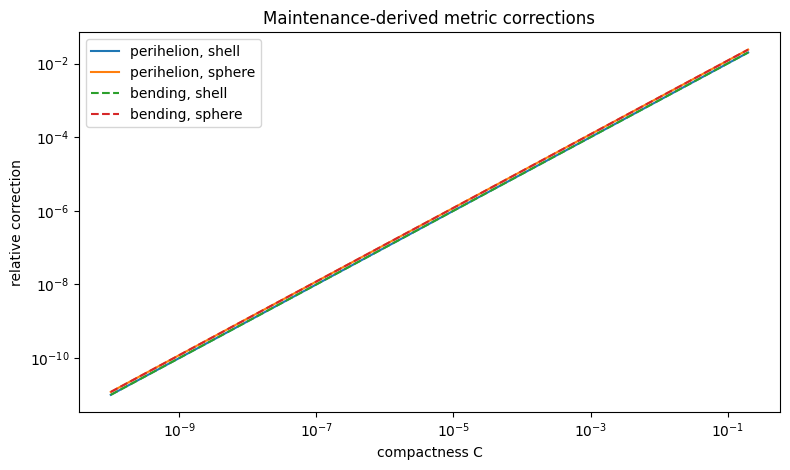

In [4]:

# Plot correction scale vs compactness for shape factors
C_vals = np.logspace(-10, -0.7, 500)
alpha_shell = 0.5
alpha_sphere = 0.6

delta_peri_shell = ((2*zeta - xi)/3) * chi * alpha_shell * C_vals
delta_peri_sphere = ((2*zeta - xi)/3) * chi * alpha_sphere * C_vals
delta_bend_shell = (zeta/2) * chi * alpha_shell * C_vals
delta_bend_sphere = (zeta/2) * chi * alpha_sphere * C_vals

plt.figure(figsize=(8,4.8))
plt.loglog(C_vals, delta_peri_shell, label="perihelion, shell")
plt.loglog(C_vals, delta_peri_sphere, label="perihelion, sphere")
plt.loglog(C_vals, delta_bend_shell, "--", label="bending, shell")
plt.loglog(C_vals, delta_bend_sphere, "--", label="bending, sphere")
plt.xlabel("compactness C")
plt.ylabel("relative correction")
plt.title("Maintenance-derived metric corrections")
plt.legend()
plt.tight_layout()
plt.show()


The shape-factor uncertainty is mild.

That is a strong sign that the branch is structurally robust at first order.

So the theory is not balancing on an arbitrary microscopic profile.
It is being driven by the coarse maintenance ratio itself.


## 6. What this notebook actually proves

This notebook does **not** derive the full boundary/reflection kernel yet.

It does prove something important:

1. compactness emerges naturally from a maintenance-energy argument,
2. the sourced metric branch survives that derivation,
3. weak-field quietness survives the derivation,
4. compact-source loudness survives the derivation,
5. leading dependence on detailed source profile is only order-unity.

That is a much stronger result than simply assuming $q_\Gamma \propto C$.


## 7. Best current theorem candidate

The cleanest current theorem candidate is now:

$$
\boxed{
E_{\mathrm{maint}}
\sim
-\alpha_s \frac{GM^2}{R},
}
$$

so that

$$
\boxed{
q_\Gamma
=
\chi\frac{|E_{\mathrm{maint}}|}{M c^2}
=
\chi \alpha_s \frac{GM}{Rc^2}.
}
$$

Then

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
E_{\mathrm{maint}}
\to
q_\Gamma
\to
(\beta_\Gamma,\gamma_\Gamma)
\to
\text{effective metric}
\to
\text{precession, lensing, clock shift}.
}
$$

In plain terms:

$$
\boxed{
\text{gravity is the first metric implementation of runtime persistence, and compactness is the dimensionless maintenance fraction of a closure.}
}
$$


## 8. Next exact move

The next continuation is now sharply defined.

We must derive the maintenance energy

$$
E_{\mathrm{maint}}
$$

from the reflection / boundary law rather than borrowing its form from self-energy analogy alone.

That is the next real boundary.

But now the branch is much cleaner:

- the sign works,
- the regime works,
- the magnitude hierarchy works,
- and compactness has a reason.
